In [3]:
import pandas as pd
import os

# Definiamo i percorsi
proc_path = 'data/processed/'

print("Caricamento dati puliti...")
# Carichiamo i file che abbiamo salvato nel notebook 01
nodes_cleaned = pd.read_csv(os.path.join(proc_path, 'nodes_cleaned.csv'))
edges_cleaned = pd.read_csv(os.path.join(proc_path, 'edges_cleaned.csv'))

print(f"Dati pronti! Nodi: {len(nodes_cleaned)}, Archi: {len(edges_cleaned)}")

Caricamento dati puliti...
Dati pronti! Nodi: 88130, Archi: 219302


In [5]:
# Il CELEX del Regolamento Golden Power (UE 2019/452)
seed_celex = '32019R0452'

# 1. Trova l'ID interno del seme
seed_node = nodes_cleaned[nodes_cleaned['celex'] == seed_celex]
if seed_node.empty:
    print(f"Errore: CELEX {seed_celex} non trovato!")
else:
    seed_id = seed_node.iloc[0]['id']
    
    # 2. Trova i vicini (chi cita il seme e chi è citato dal seme)
    # Incoming: leggi che citano la Golden Power
    # Outgoing: leggi citate dalla Golden Power (basi legali)
    connections = edges_cleaned[(edges_cleaned['source'] == seed_id) | (edges_cleaned['target'] == seed_id)]
    
    # Otteniamo tutti gli ID dei nodi connessi
    neighbor_ids = set(connections['source']) | set(connections['target'])
    
    # 3. Estrai i dettagli di queste leggi
    golden_power_network = nodes_cleaned[nodes_cleaned['id'].isin(neighbor_ids)]
    
    print(f"Trovate {len(golden_power_network)} leggi connesse alla Golden Power.")

Trovate 39 leggi connesse alla Golden Power.


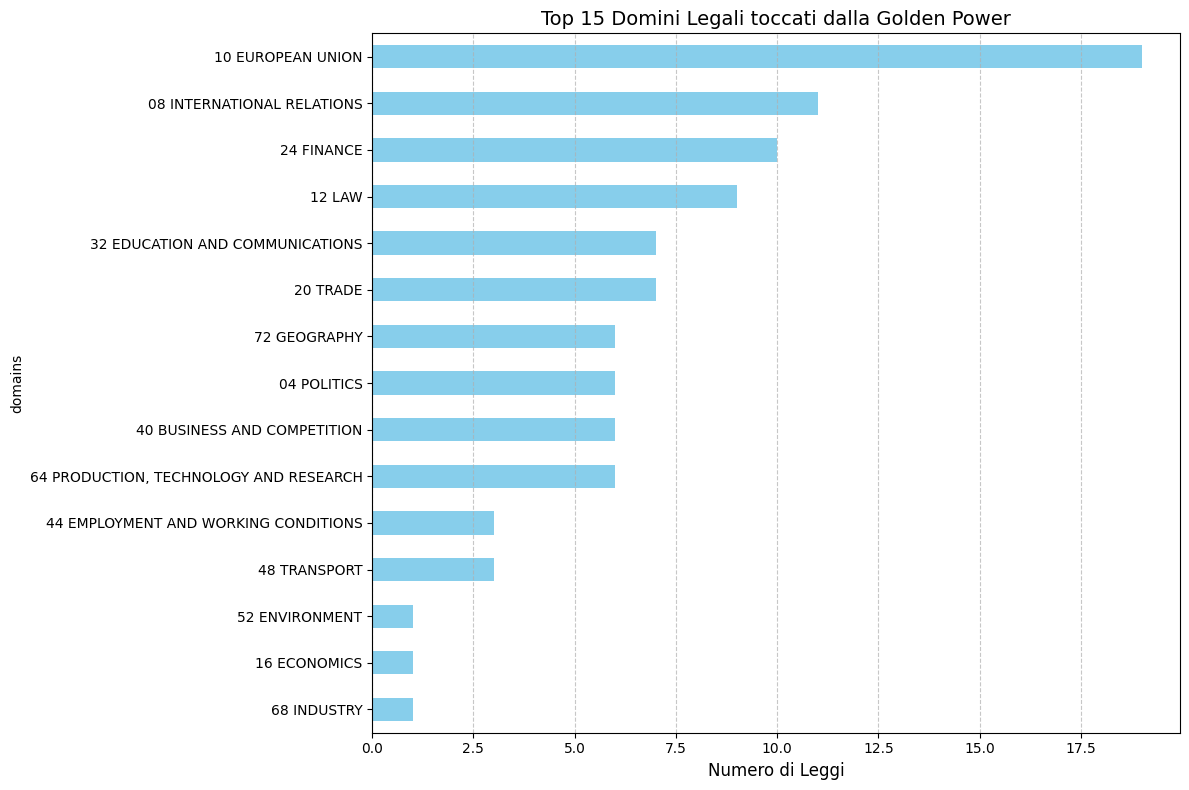

In [7]:
# 1. Rompiamo le stringhe in liste e "esplodiamole"
# Trasformiamo 'A;B;C' in tre righe distinte: A, B e C
domains_exploded = golden_power_network['domains'].dropna().str.split(';').explode()

# 2. Puliamo eventuali spazi bianchi ai bordi
domains_exploded = domains_exploded.str.strip()

# 3. Contiamo le occorrenze dei singoli domini
clean_domain_counts = domains_exploded.value_counts()

# 4. Creiamo un grafico molto più chiaro
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
clean_domain_counts.head(15).plot(kind='barh', color='skyblue') # Usiamo barre orizzontali per leggere meglio i nomi
plt.title("Top 15 Domini Legali toccati dalla Golden Power", fontsize=14)
plt.xlabel("Numero di Leggi", fontsize=12)
plt.gca().invert_yaxis() # Mette il più frequente in alto
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()